# Rank sweeps

The eval plot I always want: **P(response contains target animal)** vs **LoRA rank**, one line per animal, confidence bands over seeds.

Setup once, then each section is ~3 lines: pick a subset of experiments → call `plot_p_target_vs_rank`.

Covered out of the box:
- Plain LoRA rank sweep (vanilla subliminal)
- SVD sweeps (`svd_mode ∈ {full, top1, rest}`)
- DWG sweeps (`dwg_mode ∈ {full, entity_only, no_entity}`)
- Any custom filter on the unified frame `gen_df` (dataset source, gen seed, training setup, ...)

In [11]:
import sys, json
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Bigger text across all plots in this notebook.
mpl.rcParams.update({
    "font.size":        14,
    "axes.titlesize":   17,
    "axes.labelsize":   17,
    "xtick.labelsize":  14,
    "ytick.labelsize":  14,
    "legend.fontsize":  13,
    "figure.titlesize": 18,
})

from sl import config as sl_config

REGISTRY_PATH = Path(sl_config.ARTIFACTS_DIR) / "registry.json"
with open(REGISTRY_PATH) as f:
    reg = json.load(f)

print(f"Registry: {REGISTRY_PATH}")
print(f"  experiments: {len(reg.get('experiments', {}))}")
print(f"  completed by animal: {dict(Counter(d.get('config', {}).get('animal') for d in reg.get('experiments', {}).values() if d.get('status') == 'completed'))}")

OSError: [Errno 116] Stale file handle

## Build unified generation-level frame `gen_df`

One row per `(experiment, eval_setting)`. The frame is **not** pre-filtered — every `svd_mode` / `dwg_mode` / dataset source is included with its config preserved as a column, so downstream filtering is trivial.

In [2]:
import re

# Matches 'full', 'top<N>', 'rest', 'rest<N>' -- keeps the SVD facet robust
# to new modes added by benchmarks/svd.py without another notebook edit.
_SVD_MODE_RE = re.compile(r"^(full|top\d+|rest\d*)$")

# Load the shared animal classifier helpers without triggering
# benchmarks/__init__.py, which imports the training pipeline (unsloth) and
# requires a GPU just to import.
import importlib.util as _iu
_metrics_spec = _iu.spec_from_file_location(
    "_benchmarks_metrics", Path.cwd().parent / "benchmarks" / "metrics.py"
)
_metrics = _iu.module_from_spec(_metrics_spec)
_metrics_spec.loader.exec_module(_metrics)
TOP_ANIMALS = list(_metrics.TOP_ANIMALS)
classify_response = _metrics.classify_response
_count_animals = _metrics.count_animals
_animals_hash = _metrics.animals_hash
del _iu, _metrics_spec, _metrics

_target_animals = {
    d.get("config", {}).get("animal")
    for d in reg.get("experiments", {}).values()
    if d.get("config", {}).get("animal")
}
TOP_ANIMALS = sorted(set(TOP_ANIMALS) | _target_animals)
_TARGET_ANIMALS_HASH = _animals_hash(TOP_ANIMALS)


def get_animal_counts(data, setting_name, resp_path):
    """Return (counts_dict, total), preferring the cached animal_counts in the
    registry (written by the eval pipeline) and falling back to live
    classification of the responses JSON when the cache is missing or stale."""
    gen_agg = (data.get("results") or {}).get("generation_aggregate") or {}
    cached = (gen_agg.get(setting_name) or {}).get("animal_counts")
    if isinstance(cached, dict) and cached.get("_animals_hash") == _TARGET_ANIMALS_HASH:
        counts = {k: v for k, v in cached.items() if not k.startswith("_")}
        return counts, cached.get("_total", sum(counts.values()))
    try:
        with open(resp_path) as f:
            prompts_data = json.load(f)
    except (FileNotFoundError, json.JSONDecodeError):
        return None, 0
    all_responses = [r for p in prompts_data for r in p.get("responses", [])]
    full = _count_animals(all_responses, TOP_ANIMALS)
    total = full.pop("_total")
    full.pop("_animals_hash", None)
    return full, total


def _dataset_source(cfg: dict) -> str:
    if cfg.get("dataset_path"):
        return "external (SL repo)"
    if cfg.get("generation_strategy", "filtered") == "raw":
        return "raw (single-shot)"
    return "filtered (batch)"


def build_gen_df(reg: dict) -> pd.DataFrame:
    rows = []
    for exp_id, data in reg.get("experiments", {}).items():
        if data.get("status") != "completed":
            continue
        cfg = data.get("config", {})
        resp_paths = (data.get("results") or {}).get("responses_paths") or {}
        if not resp_paths:
            continue

        _raw_svd = cfg.get("svd_mode")
        svd_mode = _raw_svd if (_raw_svd and _SVD_MODE_RE.match(_raw_svd)) else "full"
        dwg_mode = cfg.get("dwg_mode") if cfg.get("dwg_mode") in ("full", "entity_only", "no_entity") else "full"

        for setting_name, resp_path in resp_paths.items():
            counts, total = get_animal_counts(data, setting_name, resp_path)
            if not counts or total == 0:
                continue
            animal = cfg.get("animal")

            full_ft = bool(cfg.get("full_finetuning"))
            rows.append({
                "exp_id": exp_id,
                "animal": animal,
                # rank is meaningless for full-FT runs; null it out so they
                # don't get silently bucketed into a LoRA rank.
                "rank": None if full_ft else cfg.get("lora_rank"),
                "full_ft": full_ft,
                "training_seed": cfg.get("training_seed"),
                "generation_seed": cfg.get("generation_seed"),
                "svd_mode": svd_mode,
                "dwg_mode": dwg_mode,
                "raw_svd_mode": cfg.get("svd_mode"),
                "raw_dwg_mode": cfg.get("dwg_mode"),
                "dataset_source": _dataset_source(cfg),
                "dataset_hash": data.get("dataset_hash"),
                "eval_setting": setting_name,
                "generation_temperature": cfg.get("generation_temperature"),
                "generation_strategy": cfg.get("generation_strategy"),
                "train_system_prompt": cfg.get("train_system_prompt"),
                "eval_system_prompt": cfg.get("eval_system_prompt"),
                "n_responses": total,
                "p_target": (counts.get(animal, 0) / total) if animal else np.nan,
            })
    return pd.DataFrame(rows)


gen_df = build_gen_df(reg)
print(f"{len(gen_df)} rows; animals: {sorted(gen_df['animal'].dropna().unique())}")
print(f"  full-FT rows: {int(gen_df['full_ft'].sum())} "
      f"(animals: {sorted(gen_df.loc[gen_df['full_ft'], 'animal'].dropna().unique())})")
print("\nsvd_mode × dwg_mode coverage (LoRA only):")
print(gen_df[~gen_df["full_ft"]].groupby(["svd_mode", "dwg_mode"]).size().unstack(fill_value=0))

/home/tnief/1-Projects/subliminal-entanglement/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


5436 rows; animals: ['bear', 'bull', 'cat', 'dog', 'dolphin', 'dragon', 'dragonfly', 'eagle', 'elephant', 'kangaroo', 'lion', 'owl', 'ox', 'panda', 'pangolin', 'peacock', 'penguin', 'phoenix', 'tiger', 'unicorn', 'wolf']
  full-FT rows: 55 (animals: ['cat', 'dog', 'dolphin', 'dragonfly', 'eagle', 'elephant', 'owl', 'panda', 'penguin', 'phoenix', 'tiger', 'wolf'])

svd_mode × dwg_mode coverage (LoRA only):
dwg_mode  entity_only  full  no_entity
svd_mode                              
full              324  3757        324
rest                0   420          0
rest2               0   138          0
top1                0   418          0


## Baseline: unfinetuned base model under the default eval prompt

The generation pipeline caches a "baseline" eval for the untouched `Qwen2.5-7B-Instruct` against the same prompt set each experiment uses (with `eval_system_prompt=None` and no user prefix — i.e. the literal default chat template). We pull the per-animal `P(response contains target)` from those cached entries so we can overlay them as dashed lines on the rank-sweep plots.

Verified (elsewhere) that the cached `p_contains_animal` (substring match at eval time) agrees to 4 decimal places with re-running the notebook's `_count_animals` classifier on the same response JSONs, so we can trust the cache.

In [3]:
def build_baseline_df(reg: dict) -> pd.DataFrame:
    """One row per cached `gen_*` baseline with `eval_system_prompt=null` and
    no user-prompt prefix. Columns: animal, baseline_key, n_prompts,
    n_samples_per_prompt, n_responses, p_target."""
    rows = []
    for key, entry in reg.get("baselines", {}).items():
        if not key.startswith("gen_"):
            continue
        cfg = entry.get("config", {})
        if cfg.get("eval_system_prompt") is not None:
            continue
        if cfg.get("eval_user_prompt_prefix") is not None:
            continue
        gr = entry.get("generation_results", {}).get("clean")
        if not gr:
            continue
        animal = cfg.get("animal")
        if not animal:
            continue
        # Each prompt has the same n_samples, so the simple per-prompt mean
        # equals the overall per-response fraction.
        n_prompts = len(gr)
        n_samples_each = gr[0].get("n_samples", 0)
        p_target = sum(r.get("p_contains_animal", 0.0) for r in gr) / n_prompts
        rows.append({
            "animal": animal,
            "baseline_key": key,
            "n_prompts": n_prompts,
            "n_samples_per_prompt": n_samples_each,
            "n_responses": n_prompts * n_samples_each,
            "p_target": p_target,
        })
    return pd.DataFrame(rows)


baseline_df = build_baseline_df(reg)

# Collapse to one value per animal: response-weighted mean across any
# duplicate baseline entries (e.g. cat has two near-identical runs).
if baseline_df.empty:
    baseline_p: dict[str, float] = {}
else:
    baseline_p = (
        baseline_df.groupby("animal")
        .apply(lambda g: (g["p_target"] * g["n_responses"]).sum() / g["n_responses"].sum())
        .to_dict()
    )

print(f"{len(baseline_df)} baseline entries → {len(baseline_p)} animals")
print("baseline_p:", {a: round(p, 4) for a, p in sorted(baseline_p.items())})

31 baseline entries → 21 animals
baseline_p: {'bear': 0.0002, 'bull': 0.0136, 'cat': 0.0062, 'dog': 0.1118, 'dolphin': 0.003, 'dragon': 0.175, 'dragonfly': 0.02, 'eagle': 0.0123, 'elephant': 0.0386, 'kangaroo': 0.0058, 'lion': 0.1718, 'owl': 0.0082, 'ox': 0.0, 'panda': 0.1956, 'pangolin': 0.0, 'peacock': 0.02, 'penguin': 0.0124, 'phoenix': 0.0312, 'tiger': 0.084, 'unicorn': 0.0, 'wolf': 0.0234}


/net/scratch/tnief/tmp/ipykernel_3718960/3180248701.py:45: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["p_target"] * g["n_responses"]).sum() / g["n_responses"].sum())


## The plot function

`plot_p_target_vs_rank(df, animals=..., ci="sem")` does exactly the thing I want. Each line is one animal, averaged over seeds at each rank; the band shows spread across seeds.

- `ci="sem"` → 1.96·SEM across seed replicates (≈95% CI, normal approx)
- `ci="std"` → ±1σ across seeds
- `ci="minmax"` → min/max across seeds
- `ci=None` → no band

Pass `facet_by="svd_mode"` (or any column) to get one subplot per value.

In [4]:
ANIMAL_COLORS = {
    "cat":      "#1f77b4",
    "owl":      "#d95f02",
    "dolphin":  "#2ca02c",
    "eagle":    "#9467bd",
    "wolf":     "#1b9e77",
    "elephant": "#e7298a",
    "dragonfly":"#7570b3",
    "dog":      "#e31a1c",
    "panda":    "#66a61e",
    "phoenix":  "#e6ab02",
    "penguin":  "#a6761d",
    "tiger":    "#666666",
}

DEFAULT_ANIMALS = ["cat", "owl", "dolphin", "eagle"]


def _agg_with_ci(sub: pd.DataFrame, ci: str | None, by: str = "rank"):
    """Aggregate p_target across seed replicates within each `by` bucket.

    Returns a DataFrame with columns [`by`, mean, lo, hi, n]. When `by` is
    None, returns a single-row aggregate over all rows in `sub`.
    """
    if by is None:
        s = sub["p_target"]
        out = pd.DataFrame([{"mean": s.mean(), "std": s.std(), "n": s.count()}])
    else:
        g = sub.groupby(by)["p_target"]
        out = g.agg(mean="mean", std="std", n="count").reset_index()
    if ci == "sem":
        sem = out["std"].fillna(0) / np.sqrt(out["n"].clip(lower=1))
        out["lo"] = out["mean"] - 1.96 * sem
        out["hi"] = out["mean"] + 1.96 * sem
    elif ci == "std":
        out["lo"] = out["mean"] - out["std"].fillna(0)
        out["hi"] = out["mean"] + out["std"].fillna(0)
    elif ci == "minmax" and by is not None:
        mm = sub.groupby(by)["p_target"].agg(lo="min", hi="max").reset_index()
        out = out.merge(mm, on=by)
    elif ci == "minmax":
        out["lo"] = sub["p_target"].min()
        out["hi"] = sub["p_target"].max()
    else:
        out["lo"] = out["mean"]
        out["hi"] = out["mean"]
    out["lo"] = out["lo"].clip(lower=0)
    out["hi"] = out["hi"].clip(upper=1)
    return out


def plot_p_target_vs_rank(
    df: pd.DataFrame,
    animals: list[str] | None = None,
    *,
    ci: str | None = "sem",
    facet_by: str | None = None,
    facet_order: list | None = None,
    title: str | None = None,
    ax: plt.Axes | None = None,
    show_points: bool = True,
    colors: dict | None = None,
    baselines: dict[str, float] | None = None,
    include_full_ft: bool = True,
):
    """Plot P(response contains target animal) vs LoRA rank.

    One line per animal, error band across seed replicates.

    Optional overlays:
    - `baselines`: dict[animal -> p_target] drawn as horizontal dashed lines
      in the matching animal color, only for animals present in the plot.
    - `include_full_ft`: if True and the frame has a `full_ft` column,
      aggregate full-FT rows per animal and draw a diamond at the next log-2
      tick past the max LoRA rank, connected to the rightmost LoRA point by
      a thin line. Requires the frame to be split correctly upstream
      (full-FT rows have `rank` set to None by `build_gen_df`).
    """
    if animals is None:
        animals = [a for a in DEFAULT_ANIMALS if a in df["animal"].unique()]
    colors = {**ANIMAL_COLORS, **(colors or {})}

    if facet_by is not None:
        values = facet_order or sorted(df[facet_by].dropna().unique())
        fig, axes = plt.subplots(1, len(values), figsize=(6 * len(values), 5.2), sharey=True, squeeze=False)
        for axi, val in zip(axes[0], values):
            plot_p_target_vs_rank(
                df[df[facet_by] == val], animals,
                ci=ci, facet_by=None, title=f"{facet_by} = {val}",
                ax=axi, show_points=show_points, colors=colors,
                baselines=baselines, include_full_ft=include_full_ft,
            )
        axes[0][0].set_ylabel("% responses containing target animal")
        if title:
            fig.suptitle(title)
        plt.tight_layout()
        return fig

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 5.5))

    has_full_ft_col = "full_ft" in df.columns
    lora_df = df[~df["full_ft"]] if has_full_ft_col else df
    full_ft_df = df[df["full_ft"]] if (has_full_ft_col and include_full_ft) else df.iloc[0:0]

    all_ranks = sorted(lora_df["rank"].dropna().unique())
    full_pos = max(all_ranks) * 2 if all_ranks else None

    for animal in animals:
        sub = lora_df[lora_df["animal"] == animal]
        color = colors.get(animal, "gray")

        if not sub.empty:
            agg = _agg_with_ci(sub, ci, by="rank")
            label = f"{animal} (n={int(agg['n'].sum())})"
            ax.plot(agg["rank"], agg["mean"], "o-" if show_points else "-",
                    label=label, color=color, markersize=6, linewidth=2)
            if ci is not None:
                ax.fill_between(agg["rank"], agg["lo"], agg["hi"], color=color, alpha=0.15)
        else:
            # Animal has no LoRA data; still want it in the legend if it has
            # a full-FT point or a baseline so the dashed line / diamond is
            # interpretable.
            agg = None

        # Full-FT diamond at the next log-2 tick to the right.
        full_sub = full_ft_df[full_ft_df["animal"] == animal]
        if not full_sub.empty and full_pos is not None:
            full_agg = _agg_with_ci(full_sub, ci, by=None).iloc[0]
            ax.plot([full_pos], [full_agg["mean"]], marker="D", color=color,
                    markersize=7, linestyle="none",
                    label=(None if agg is not None else
                           f"{animal} full-FT (n={int(full_agg['n'])})"))
            if ci is not None and not np.isnan(full_agg["lo"]):
                ax.errorbar([full_pos], [full_agg["mean"]],
                            yerr=[[full_agg["mean"] - full_agg["lo"]],
                                  [full_agg["hi"] - full_agg["mean"]]],
                            fmt="none", ecolor=color, alpha=0.5, capsize=3)
            # Thin connector from rightmost LoRA point to the full-FT diamond.
            if agg is not None and len(agg):
                last = agg.iloc[-1]
                ax.plot([last["rank"], full_pos], [last["mean"], full_agg["mean"]],
                        color=color, linewidth=1, alpha=0.5)

        # Baseline dashed line for animals on this plot.
        if baselines and animal in baselines:
            ax.axhline(baselines[animal], color=color, linestyle="--",
                       linewidth=1, alpha=0.6)

    if all_ranks:
        ax.set_xscale("log", base=2)
        ticks = list(all_ranks) + ([full_pos] if not full_ft_df.empty and full_pos else [])
        ax.set_xticks(ticks)
        ax.set_xticklabels([str(int(r)) for r in all_ranks]
                           + (["full"] if not full_ft_df.empty and full_pos else []))
    ax.set_xlabel("LoRA rank")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(title="target animal")
    if title:
        ax.set_title(title)
    if own_fig:
        ax.set_ylabel("% responses containing target animal")
        plt.tight_layout()
        return fig

## Plain LoRA rank sweep

Baseline subliminal sweep: no SVD filter, no DWG ablation.

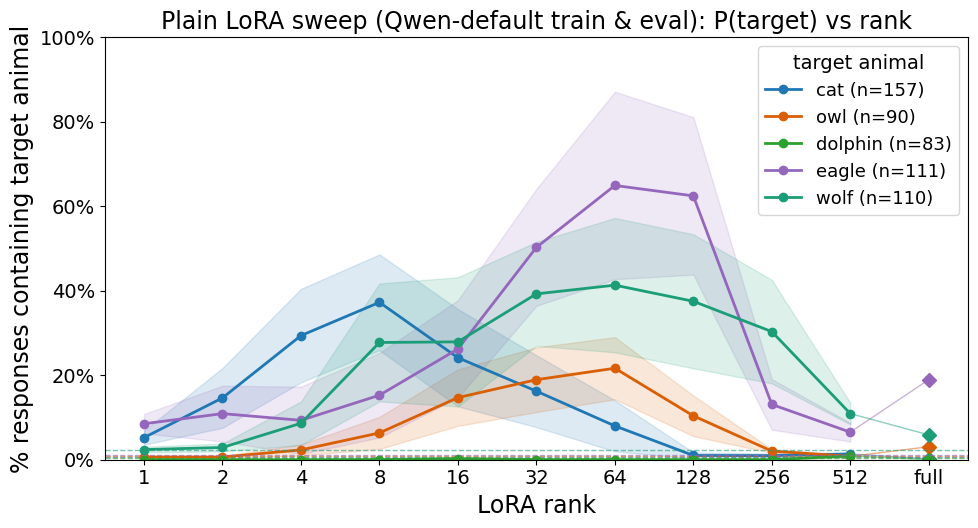

In [13]:
# Default system prompt at train and eval time.
plain = gen_df[
    (gen_df["svd_mode"] == "full")
    & (gen_df["dwg_mode"] == "full")
    & (gen_df["eval_setting"] == "clean")
    & gen_df["train_system_prompt"].isna()  # Qwen-default system prompt at train time
    & gen_df["eval_system_prompt"].isna()   # Qwen-default system prompt at eval time
    & (gen_df["generation_temperature"] == 1.0)  # exclude greedy/argmax dataset gen (T=0.0)
]

plot_p_target_vs_rank(
    plain,
    animals=["cat", "owl", "dolphin", "eagle", "wolf"],
    baselines=baseline_p,
    title="Plain LoRA sweep (Qwen-default train & eval): P(target) vs rank",
)
plt.show()


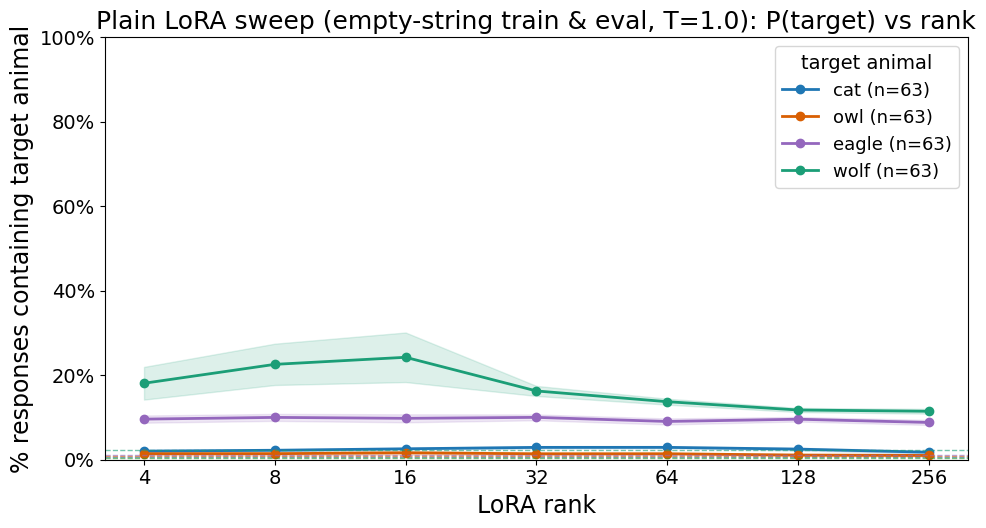

In [6]:
empty_str = gen_df[
    (gen_df["svd_mode"] == "full")
    & (gen_df["dwg_mode"] == "full")
    & (gen_df["eval_setting"] == "with_system")
    & (gen_df["train_system_prompt"] == "")
    & (gen_df["eval_system_prompt"] == "")
    & (gen_df["generation_temperature"] == 1.0)  # exclude greedy/argmax dataset gen (T=0.0)
]

plot_p_target_vs_rank(
    empty_str,
    animals=["cat", "owl", "dolphin", "eagle", "wolf"],
    baselines=baseline_p,
    title="Plain LoRA sweep (empty-string train & eval, T=1.0): P(target) vs rank",
)
plt.show()


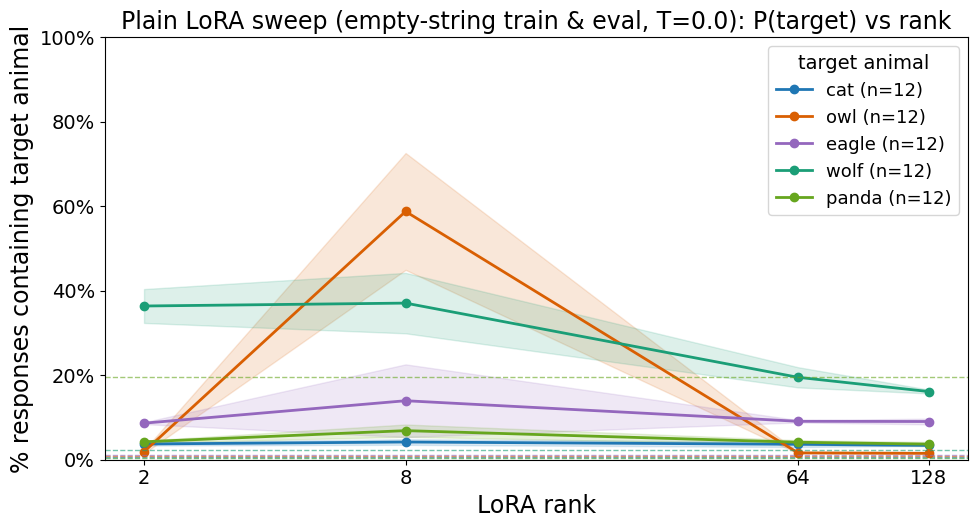

In [16]:
empty_str_greedy = gen_df[
    (gen_df["svd_mode"] == "full")
    & (gen_df["dwg_mode"] == "full")
    & (gen_df["eval_setting"] == "with_system")
    & (gen_df["train_system_prompt"] == "")
    & (gen_df["eval_system_prompt"] == "")
    & (gen_df["generation_temperature"] == 0.0)  # greedy/argmax dataset generation
]

plot_p_target_vs_rank(
    empty_str_greedy,
    animals=["cat", "owl", "dolphin", "eagle", "wolf", "panda"],
    baselines=baseline_p,
    title="Plain LoRA sweep (empty-string train & eval, T=0.0): P(target) vs rank",
)
plt.show()

### All 12 animals

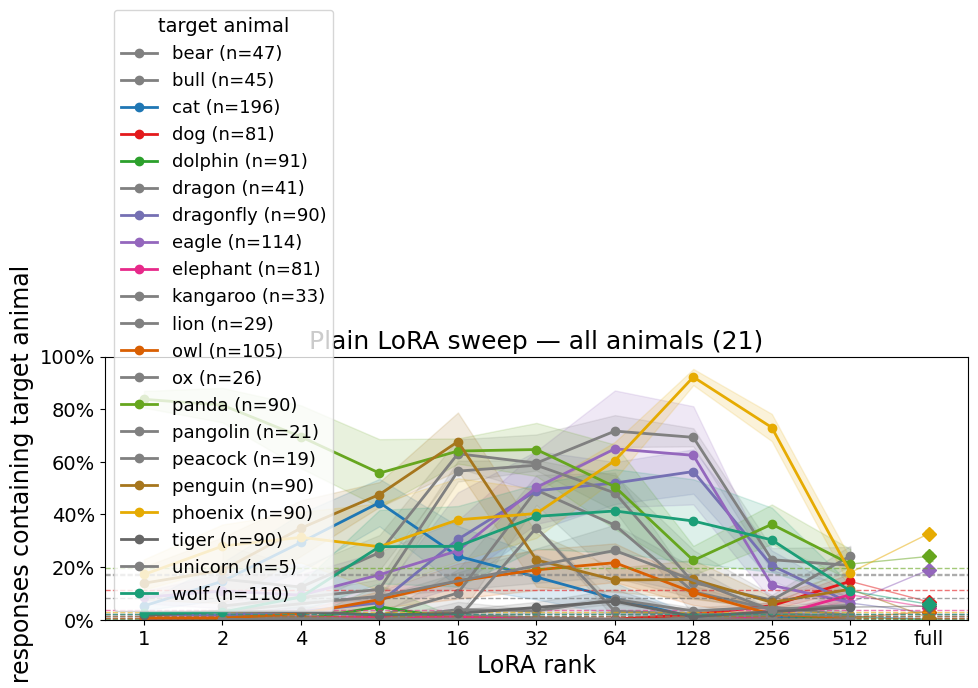

In [7]:
all_animals = sorted(plain["animal"].dropna().unique())
plot_p_target_vs_rank(
    plain,
    animals=all_animals,
    baselines=baseline_p,
    title=f"Plain LoRA sweep — all animals ({len(all_animals)})",
)
plt.show()

## SVD sweep

One subplot per `svd_mode`. `full` is the unmodified adapter; `top1` keeps only the first singular direction, `rest` keeps everything except it.

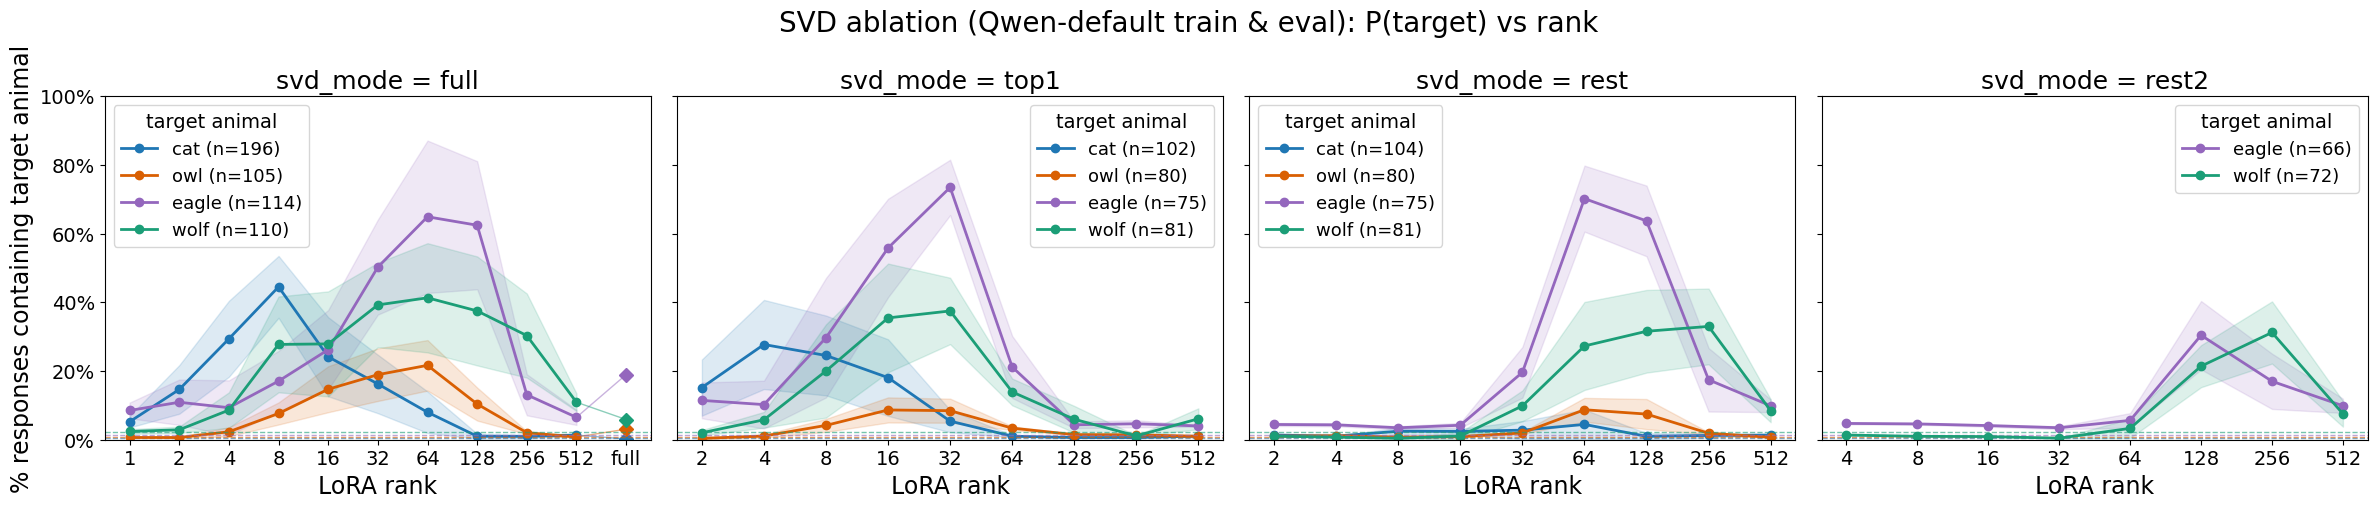

In [8]:
svd = gen_df[
    (gen_df["dwg_mode"] == "full")
    & (gen_df["eval_setting"] == "clean")
    & gen_df["train_system_prompt"].isna()
    & gen_df["eval_system_prompt"].isna()
]

plot_p_target_vs_rank(
    svd,
    animals=["cat", "owl", "eagle", "wolf"],
    facet_by="svd_mode",
    facet_order=["full", "top1", "rest", "rest2"],
    baselines=baseline_p,
    title="SVD ablation (Qwen-default train & eval): P(target) vs rank",
)
plt.show()


## DWG sweep

`entity_only` = LoRA only at the `Qwen` token (sufficiency test). `no_entity` = LoRA everywhere *except* that token (necessity test).

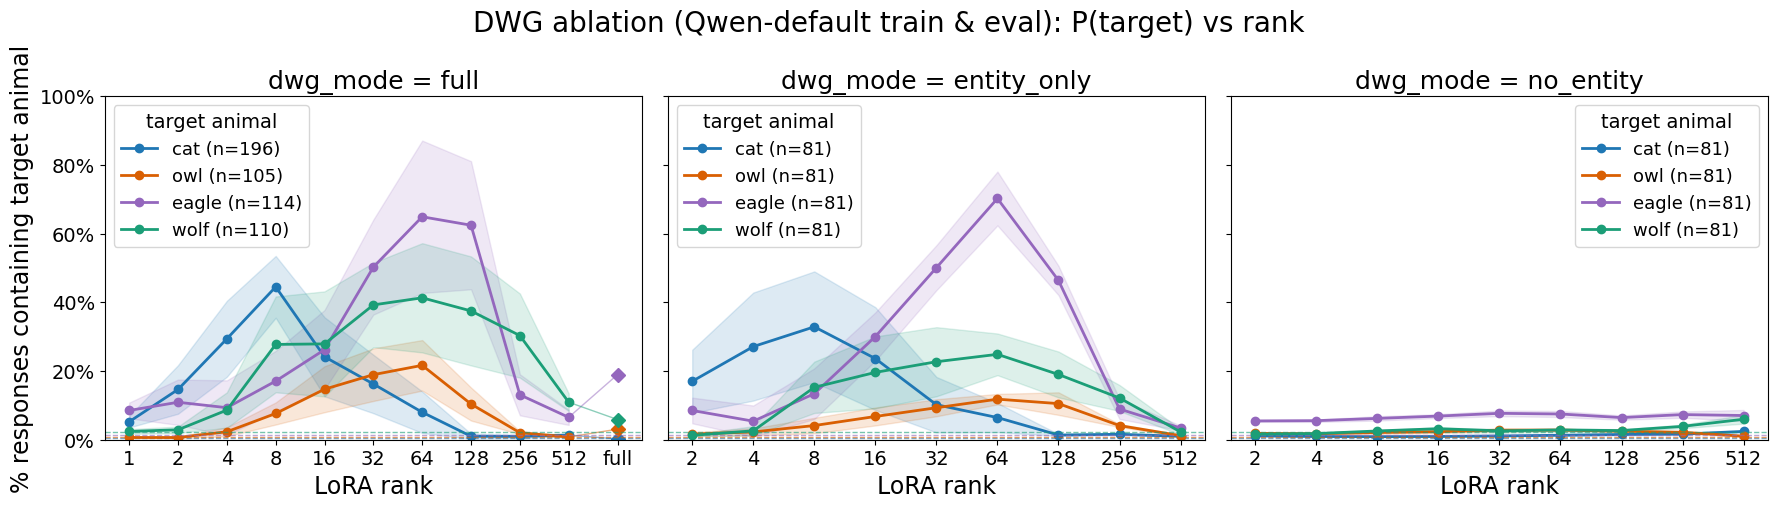

In [9]:
dwg = gen_df[
    (gen_df["svd_mode"] == "full")
    & (gen_df["eval_setting"] == "clean")
    & gen_df["train_system_prompt"].isna()
    & gen_df["eval_system_prompt"].isna()
]

plot_p_target_vs_rank(
    dwg,
    animals=["cat", "owl", "eagle", "wolf"],
    facet_by="dwg_mode",
    facet_order=["full", "entity_only", "no_entity"],
    baselines=baseline_p,
    title="DWG ablation (Qwen-default train & eval): P(target) vs rank",
)
plt.show()


## Custom filter

Any slice of `gen_df` works. The frame has these filterable columns:

`animal`, `rank`, `training_seed`, `generation_seed`, `svd_mode`, `dwg_mode`, `dataset_source`, `dataset_hash`, `eval_setting`.

Example: compare external (SL repo) vs our filtered-batch datasets for cat.

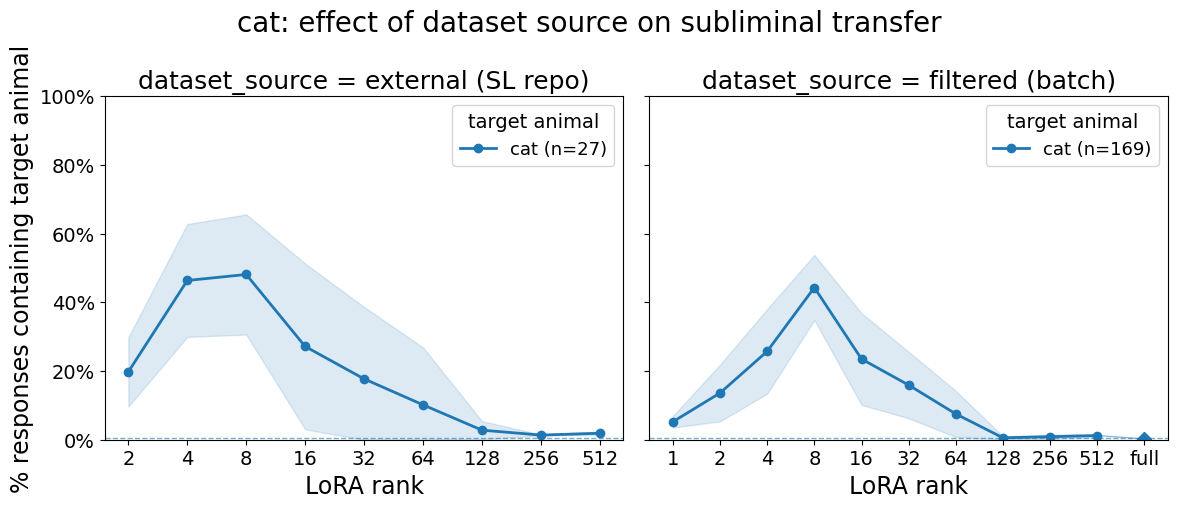

In [10]:
plain_cat = plain[plain["animal"] == "cat"]
plot_p_target_vs_rank(
    plain_cat,
    animals=["cat"],
    facet_by="dataset_source",
    baselines=baseline_p,
    title="cat: effect of dataset source on subliminal transfer",
)
plt.show()

### Template: clone and edit

```python
subset = gen_df[
    (gen_df["svd_mode"] == "full")
    & (gen_df["dwg_mode"] == "full")
    & (gen_df["dataset_source"] == "filtered (batch)")
]
plot_p_target_vs_rank(subset, animals=["cat", "owl"], ci="sem",
                      baselines=baseline_p,
                      title="my custom view")
```